# Entrenamiento del modelo de churn

Red neuronal (Keras) que predice si un cliente de telecomunicaciones cancelará el servicio, entrenada con el dataset *Telco Customer Churn*.

Al final se guardan dos archivos, que son los que usa la API:

- `modelo/churn_model`: la red neuronal entrenada.
- `modelo/preprocessor.pkl`: las transformaciones de los datos de entrada.

## 1. Carga y revisión de los datos

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('../data/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print(df.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 2. Limpieza

Se codifica la variable objetivo como 0/1. `TotalCharges` llega como texto: se convierte a número y se eliminan las pocas filas que quedan vacías.

In [5]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Pasar a numericos los datos de TotalCharges y poner NaN en los que no se pueda

In [7]:
df = df.dropna()
# Eliminar los NaN

## 3. Variables de entrada y objetivo

Se separa la variable objetivo y se elimina `customerID`, que es un identificador y no aporta información.

In [8]:
# Antes de dividir los datos se deben realizar las transformaciones necesarias con los datos junto.
# De lo contrario se podría generar que una de las dos paribles tenga más datos que la otra.
# Causando un error en split.

X = df.drop('Churn', axis=1)
y = df['Churn']

In [9]:
X.isna().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [10]:
X.select_dtypes(include='object').nunique().sort_values(ascending=False)

customerID          7032
PaymentMethod          4
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
gender                 2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
dtype: int64

In [11]:
X = X.drop('customerID', axis=1)

## 4. Preprocesamiento

Las variables numéricas se estandarizan y las categóricas se convierten con *one-hot encoding*. Todo queda dentro de un `ColumnTransformer` para poder guardarlo y aplicar exactamente las mismas transformaciones en producción.

In [12]:
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns


In [13]:
print("Categóricas:", list(categorical_cols))
print("Numéricas:", list(numeric_cols))

Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [15]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Rellenar los NaN con la mediana
    ('scaler', StandardScaler()) # Estandarizar los datos
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Rellenar los NaN con el valor más frecuente
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Convertir las categorías en variables dummy
])

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_cols), # Aplicar el pipeline de transformación numérica
        ('cat', categorical_transformer, categorical_cols) # Aplicar el pipeline de transformación categórica
    ])

## 5. División en entrenamiento y prueba

80 % para entrenar y 20 % para evaluar. Se usa `stratify=y` porque la variable objetivo está desbalanceada. El preprocesador se ajusta solo con los datos de entrenamiento.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# En problemas de clasificación, poner stratify=y para que los datos se distribuyan de manera equitativa en las dos particiones.
# En problemas de regresión, no es necesario.


In [25]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


In [26]:
input_shape = X_train_preprocessed.shape[1]
output_shape = 1

## 6. Modelo

Red neuronal densa con dos capas ocultas (64 y 32 neuronas, ReLU) y una salida sigmoide, que devuelve la probabilidad de cancelación.

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(input_shape,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(output_shape, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

## 7. Entrenamiento

In [55]:


# fit the model
modelo = model.fit(X_train_preprocessed, y_train, validation_data=(X_test_preprocessed   , y_test), epochs=20, verbose=2)

Epoch 1/20


176/176 - 11s - loss: 0.4582 - accuracy: 0.7760 - precision: 0.6085 - recall: 0.4408 - auc: 0.8035 - val_loss: 0.4309 - val_accuracy: 0.7953 - val_precision: 0.6257 - val_recall: 0.5722 - val_auc: 0.8329 - 11s/epoch - 60ms/step
Epoch 2/20
176/176 - 1s - loss: 0.4155 - accuracy: 0.8023 - precision: 0.6504 - recall: 0.5538 - auc: 0.8467 - val_loss: 0.4359 - val_accuracy: 0.7939 - val_precision: 0.6750 - val_recall: 0.4332 - val_auc: 0.8322 - 1s/epoch - 6ms/step
Epoch 3/20
176/176 - 1s - loss: 0.4113 - accuracy: 0.8044 - precision: 0.6584 - recall: 0.5492 - auc: 0.8502 - val_loss: 0.4306 - val_accuracy: 0.7910 - val_precision: 0.6149 - val_recall: 0.5722 - val_auc: 0.8329 - 1s/epoch - 8ms/step
Epoch 4/20
176/176 - 2s - loss: 0.4090 - accuracy: 0.8062 - precision: 0.6645 - recall: 0.5472 - auc: 0.8518 - val_loss: 0.4298 - val_accuracy: 0.7953 - val_precision: 0.6453 - val_recall: 0.5107 - val_auc: 0.8339 - 2s/epoch - 9ms/step
Epoch 5/20
176/176 - 1s - loss: 0.4050 - accuracy: 0.8068 - prec

In [56]:
modelo.history.keys()

dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])

## 8. Curvas de entrenamiento

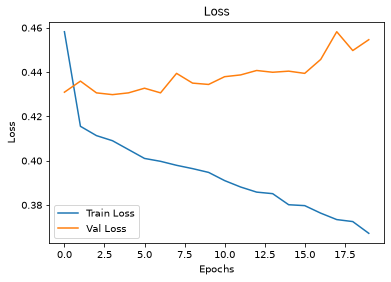

In [ ]:
import matplotlib.pyplot as plt

plt.plot(modelo.history['loss'], label='Train Loss')
plt.plot(modelo.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.show()



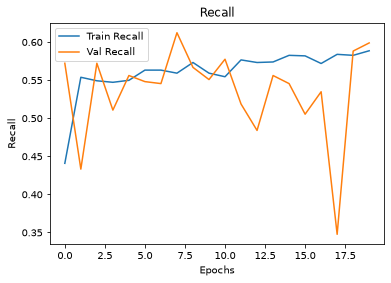

In [ ]:
plt.plot(modelo.history['recall'], label='Train Recall')
plt.plot(modelo.history['val_recall'], label='Val Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.title('Recall')
plt.show()


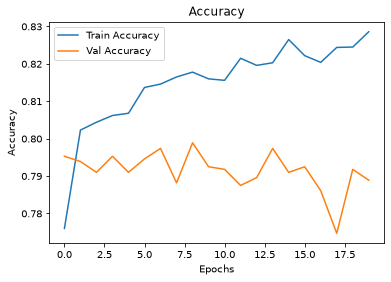

In [ ]:
import matplotlib.pyplot as plt

plt.plot(modelo.history['accuracy'], label='Train Accuracy')
plt.plot(modelo.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()


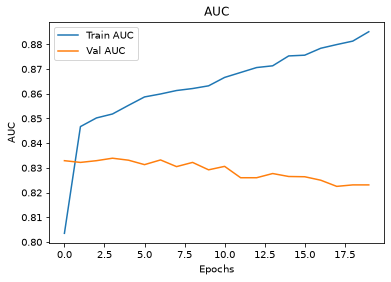

In [ ]:
plt.plot(modelo.history['auc'], label='Train AUC')
plt.plot(modelo.history['val_auc'], label='Val AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.title('AUC')
plt.show()


## 9. Guardado del modelo y del preprocesador

In [57]:
model.save("../modelo/churn_model")


In [58]:
import joblib
joblib.dump(preprocessor, "../modelo/preprocessor.pkl")
